In [33]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams.update({
    'figure.figsize': (3.6, 2.7), 'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 'small', 'ytick.labelsize': 'small',
    'legend.fontsize': 'small', 'axes.titlesize': 'medium',
    'axes.spines.top': False, 'axes.spines.right': False,
    'image.interpolation': 'nearest', 'savefig.dpi': 100,
})

import os
import pickle
from pathlib import Path
import numpy as np
import torch

from jarvis.utils import tqdm
from hexarena import STORE_DIR

FIG_DIR = Path('figures')
os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng()

# Fetch trained HMMs for one subject

In [54]:
from hexarena.scripts.identify_policies import create_manager

subject = 'viktor'
n_policies = 2

manager = create_manager(subject)

In [31]:
key = keys[0]
config = manager.configs[key]
manager.setup(config)
manager.load_ckpt(manager.ckpts[key])
config.learn

{'switch_reg': 10.0,
 'jsd_reg': 20.0,
 'l2_reg': 0.001,
 'max_steps': 800,
 'batch_size': 32}

In [28]:
alphas = torch.tensor([-1, config.learn.l2_reg, -config.learn.jsd_reg, config.learn.switch_reg])
losses = torch.cat(manager.losses)
best_epoch = np.argmin((losses*alphas).sum(dim=1).numpy()).item()
print(f'best epoch: {best_epoch}')

best epoch: 957


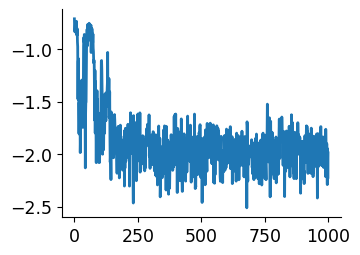

In [29]:
_, ax = plt.subplots()
ax.plot(losses[:, 3])
plt.show()

In [40]:
best_losses = []
for key in keys:
    config = manager.configs[key]
    manager.setup(config)
    manager.load_ckpt(manager.ckpts[key])
    alphas = torch.tensor([-1, config.learn.l2_reg, -config.learn.jsd_reg, config.learn.switch_reg])
    losses = torch.cat(manager.losses)
    assert (losses*alphas).sum(dim=1).min().item()==manager.min_loss, f"{key} loss inconsistent"
    best_epoch = np.argmin((losses*alphas).sum(dim=1).numpy()).item()
    best_losses.append(losses[best_epoch])
best_losses = torch.stack(best_losses).numpy()
lls, l2_regs, jsd_regs, switch_regs = best_losses.T

In [36]:
lls

array([-1.0431653 , -0.6150653 , -0.63497096, -0.44643307, -0.4603817 ,
       -1.4862362 , -1.3215668 , -0.45370585, -0.4499958 , -1.0939312 ],
      dtype=float32)

In [38]:
jsd_regs

array([0.3938405 , 0.00748984, 0.0068296 , 0.5065973 , 0.00417783,
       0.52799183, 0.24585676, 0.15624967, 0.15179375, 0.43951565],
      dtype=float32)

In [39]:
switch_regs

array([-2.4174109, -3.497643 , -3.5791473, -2.4674394, -3.8667777,
       -2.4186907, -1.4930444, -2.9143047, -2.9724476, -2.4965353],
      dtype=float32)